In [1]:
!pip install -q selenium
!pip install -q webdriver-manager
!pip install -q beautifulsoup4 fake-useragent pandas tqdm requests

!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get install -y -q ./google-chrome-stable_current_amd64.deb
!rm google-chrome-stable_current_amd64.deb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 4.3 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libatk-bridge2.0-0 libatk1.0-0
  libatk1.0-data libatspi2.0-0 libvulkan1 libxcomposite1 libxtst6
  mesa-vulkan-drivers session-migration
The following NEW packages will be installed:
  at-spi2-core google-chrome-stable gsettings-desktop-schemas
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libvulkan1
  libxcomposite1 libxtst6 mesa-vulkan-drivers session-migration
0 upgraded, 12 newly installed, 0 to remove and 2 not upgraded.
Need to get 11.2 MB/136 MB of archives.
After this operation

In [2]:
import requests
import pandas as pd
import re
from bs4 import BeautifulSoup
from tqdm import tqdm
from time import sleep
import json
import logging
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

In [3]:
config = {
    "logging_enabled": True,
    "log_level": "INFO",
    "log_file": "scraper.log"
}

In [4]:
if config['logging_enabled']:
  logging.basicConfig(
      level=getattr(logging, config['log_level'].upper(), logging.INFO),
      filename=config['log_file'],
      format='%(asctime)s - %(levelname)s - %(funcName)s - %(message)s',
      force=True,
      datefmt='%H:%M:%S')
  logging.info('Логирование включено')

In [5]:
options = Options()
options.binary_location = '/usr/bin/google-chrome'
options.add_argument('--headless=new')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
options.add_argument('--disable-gpu')

service = Service(ChromeDriverManager().install())
browser = webdriver.Chrome(service=service, options=options)
logging.info('Selenium browser успешно создан')

In [6]:
url = 'https://career.habr.com/vacancies'

page = requests.get(url)
page

<Response [200]>

In [7]:
soup = BeautifulSoup(page.text, 'html')
print(soup.prettify())

<!DOCTYPE html>
<html lang="ru">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width, initial-scale=1" name="viewport"/>
  <title>
   Работа и свежие вакансии для IT специалистов от прямых работодателей — Хабр Карьера
  </title>
  <meta content="Работа и свежие вакансии для IT специалистов в самых разных сферах IT-индустрии: программирование, верстка, дизайн, менеджмент, веб-аналитика, маркетинг и других." name="description"/>
  <meta content="Работа и свежие вакансии для IT специалистов от прямых работодателей — Хабр Карьера" property="og:title"/>
  <meta content="Работа и свежие вакансии для IT специалистов в самых разных сферах IT-индустрии: программирование, верстка, дизайн, менеджмент, веб-аналитика, маркетинг и других." property="og:description"/>
  <meta content="https://career.habr.com/images/career_share.png" property="og:image"/>
  <meta content="Работа и свежие вакансии для IT специалистов от прямых работодателей — Хабр Карьера" name="twitter:title"/>
  <me

In [8]:
url = 'https://career.habr.com/vacancies'

page = requests.get(url)
page

<Response [200]>

In [9]:
logging.info(f'Страница открывается: {url}')

In [10]:
soup = BeautifulSoup(page.text, 'html')
print(soup.prettify())

<!DOCTYPE html>
<html lang="ru">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width, initial-scale=1" name="viewport"/>
  <title>
   Работа и свежие вакансии для IT специалистов от прямых работодателей — Хабр Карьера
  </title>
  <meta content="Работа и свежие вакансии для IT специалистов в самых разных сферах IT-индустрии: программирование, верстка, дизайн, менеджмент, веб-аналитика, маркетинг и других." name="description"/>
  <meta content="Работа и свежие вакансии для IT специалистов от прямых работодателей — Хабр Карьера" property="og:title"/>
  <meta content="Работа и свежие вакансии для IT специалистов в самых разных сферах IT-индустрии: программирование, верстка, дизайн, менеджмент, веб-аналитика, маркетинг и других." property="og:description"/>
  <meta content="https://career.habr.com/images/career_share.png" property="og:image"/>
  <meta content="Работа и свежие вакансии для IT специалистов от прямых работодателей — Хабр Карьера" name="twitter:title"/>
  <me

In [11]:
for link in soup.find_all('a'):
    print(link.get('href'))

https://career.habr.com/
https://habr.com/?utm_source=habr_career&utm_medium=habr_top_panel
https://qna.habr.com/?utm_source=habr_career&utm_medium=habr_top_panel
https://career.habr.com/
https://career.habr.com/education/?utm_source=habr_career&utm_medium=habr_top_panel
https://career.habr.com/users/auth/tmid
https://career.habr.com/users/auth/tmid/register
https://career.habr.com/users/auth/tmid
https://career.habr.com/users/auth/tmid/register
https://career.habr.com/vacancies
https://career.habr.com/resumes
/education
https://career.habr.com/experts
https://career.habr.com/companies
https://career.habr.com/companies/ratings
https://career.habr.com/salaries
https://career.habr.com/journal
https://t.me/habr_seminar_bot
/announcements/492/dismiss_guest
/vacancies/1000165251
/vacancies/1000165251
/companies/loodsen
/vacancies/1000165251
/vacancies/programmist_python
/users/auth/tmid/vacancy/1000165251/response
/vacancies/1000139016
/vacancies/1000139016
/companies/psb
/companies/psb/sco

In [12]:
urls = []

for link in soup.find_all('a'):
    if '/vacancies' in link.get('href'):
        urls.append(link.get('href'))
urls

TypeError: argument of type 'NoneType' is not iterable

In [13]:
urls = []

for link in soup.find_all('a'):
    if link.get('href') is not None and '/vacancies' in link.get('href'):
        urls.append(link.get('href'))
urls

['https://career.habr.com/vacancies',
 '/vacancies/1000165251',
 '/vacancies/1000165251',
 '/vacancies/1000165251',
 '/vacancies/programmist_python',
 '/vacancies/1000139016',
 '/vacancies/1000139016',
 '/vacancies/1000139016',
 '/vacancies/skills/informatsionnaya-bezopasnost',
 '/vacancies/1000163088',
 '/vacancies/1000163088',
 '/vacancies/1000163088',
 '/vacancies/programmist_python',
 '/vacancies/skills/linux',
 '/vacancies/skills/pytest',
 '/vacancies/1000162808',
 '/vacancies/1000162808',
 '/vacancies/1000162808',
 '/vacancies/skills/informatsionnaya-bezopasnost',
 '/vacancies/1000156172',
 '/vacancies/1000156172',
 '/vacancies/1000156172',
 '/vacancies/programmist_python',
 '/vacancies/programmist_c_plus_plus',
 '/vacancies/skills/golang',
 '/vacancies/skills/algoritmy-i-struktury-dannyh',
 '/vacancies/1000165750',
 '/vacancies/1000165750',
 '/vacancies/1000165750',
 '/vacancies/skills/sap-hcm',
 '/vacancies/1000143615',
 '/vacancies/1000143615',
 '/vacancies/1000143615',
 '/vac

In [14]:
urls = []

for link in soup.find_all('a'):
    if link.get('href') is not None and '/vacancies' in link.get('href'):
        urls.append('https://career.habr.com' + link.get('href'))
urls

['https://career.habr.comhttps://career.habr.com/vacancies',
 'https://career.habr.com/vacancies/1000165251',
 'https://career.habr.com/vacancies/1000165251',
 'https://career.habr.com/vacancies/1000165251',
 'https://career.habr.com/vacancies/programmist_python',
 'https://career.habr.com/vacancies/1000139016',
 'https://career.habr.com/vacancies/1000139016',
 'https://career.habr.com/vacancies/1000139016',
 'https://career.habr.com/vacancies/skills/informatsionnaya-bezopasnost',
 'https://career.habr.com/vacancies/1000163088',
 'https://career.habr.com/vacancies/1000163088',
 'https://career.habr.com/vacancies/1000163088',
 'https://career.habr.com/vacancies/programmist_python',
 'https://career.habr.com/vacancies/skills/linux',
 'https://career.habr.com/vacancies/skills/pytest',
 'https://career.habr.com/vacancies/1000162808',
 'https://career.habr.com/vacancies/1000162808',
 'https://career.habr.com/vacancies/1000162808',
 'https://career.habr.com/vacancies/skills/informatsionnaya-

In [15]:
urls = []

for link in soup.find_all('a', href=re.compile(r'\d+$')):
    if link.get('href') is not None and '/vacancies' in link.get('href'):
        urls.append('https://career.habr.com' + link.get('href'))
urls

['https://career.habr.com/vacancies/1000165251',
 'https://career.habr.com/vacancies/1000165251',
 'https://career.habr.com/vacancies/1000165251',
 'https://career.habr.com/vacancies/1000139016',
 'https://career.habr.com/vacancies/1000139016',
 'https://career.habr.com/vacancies/1000139016',
 'https://career.habr.com/vacancies/1000163088',
 'https://career.habr.com/vacancies/1000163088',
 'https://career.habr.com/vacancies/1000163088',
 'https://career.habr.com/vacancies/1000162808',
 'https://career.habr.com/vacancies/1000162808',
 'https://career.habr.com/vacancies/1000162808',
 'https://career.habr.com/vacancies/1000156172',
 'https://career.habr.com/vacancies/1000156172',
 'https://career.habr.com/vacancies/1000156172',
 'https://career.habr.com/vacancies/1000165750',
 'https://career.habr.com/vacancies/1000165750',
 'https://career.habr.com/vacancies/1000165750',
 'https://career.habr.com/vacancies/1000143615',
 'https://career.habr.com/vacancies/1000143615',
 'https://career.hab

In [16]:
urls = []

for link in soup.find_all('a', href=re.compile(r'^/vacancies/\d+$')):
    if link.get('href') is not None and '/vacancies' in link.get('href'):
        urls.append('https://career.habr.com' + link.get('href'))
urls

['https://career.habr.com/vacancies/1000165251',
 'https://career.habr.com/vacancies/1000165251',
 'https://career.habr.com/vacancies/1000165251',
 'https://career.habr.com/vacancies/1000139016',
 'https://career.habr.com/vacancies/1000139016',
 'https://career.habr.com/vacancies/1000139016',
 'https://career.habr.com/vacancies/1000163088',
 'https://career.habr.com/vacancies/1000163088',
 'https://career.habr.com/vacancies/1000163088',
 'https://career.habr.com/vacancies/1000162808',
 'https://career.habr.com/vacancies/1000162808',
 'https://career.habr.com/vacancies/1000162808',
 'https://career.habr.com/vacancies/1000156172',
 'https://career.habr.com/vacancies/1000156172',
 'https://career.habr.com/vacancies/1000156172',
 'https://career.habr.com/vacancies/1000165750',
 'https://career.habr.com/vacancies/1000165750',
 'https://career.habr.com/vacancies/1000165750',
 'https://career.habr.com/vacancies/1000143615',
 'https://career.habr.com/vacancies/1000143615',
 'https://career.hab

In [17]:
def get_page(p):
  url = f'https://career.habr.com/vacancies?page={p}&type=all'
  response = requests.get(url)
  soup = BeautifulSoup(response.content, 'html.parser')

  urls = []

  for link in soup.find_all('a', href=re.compile(r'^/vacancies/\d+$')):
    if link.get('href') is not None and '/vacancies' in link.get('href'):
       urls.append('https://career.habr.com' + link.get('href'))
  return urls

In [18]:
get_page(3)

['https://career.habr.com/vacancies/1000166087',
 'https://career.habr.com/vacancies/1000166087',
 'https://career.habr.com/vacancies/1000166087',
 'https://career.habr.com/vacancies/1000164426',
 'https://career.habr.com/vacancies/1000164426',
 'https://career.habr.com/vacancies/1000164426',
 'https://career.habr.com/vacancies/1000133419',
 'https://career.habr.com/vacancies/1000133419',
 'https://career.habr.com/vacancies/1000133419',
 'https://career.habr.com/vacancies/1000165563',
 'https://career.habr.com/vacancies/1000165563',
 'https://career.habr.com/vacancies/1000165563',
 'https://career.habr.com/vacancies/1000166086',
 'https://career.habr.com/vacancies/1000166086',
 'https://career.habr.com/vacancies/1000166086',
 'https://career.habr.com/vacancies/1000164843',
 'https://career.habr.com/vacancies/1000164843',
 'https://career.habr.com/vacancies/1000164843',
 'https://career.habr.com/vacancies/1000165714',
 'https://career.habr.com/vacancies/1000165714',
 'https://career.hab

In [19]:
def get_page(p):
  url = f'https://career.habr.com/vacancies?page={p}&type=all'
  response = requests.get(url)
  logging.info(f'Открыта страница с ваканиями: {url}')
  soup = BeautifulSoup(response.content, 'html.parser')

  urls = []

  for link in soup.find_all('a', href=re.compile(r'^/vacancies/\d+$')):
    if link.get('href') is not None and '/vacancies' in link.get('href'):
       urls.append('https://career.habr.com' + link.get('href'))
  urls = list(set(urls))
  logging.info(f'На странице {p} найдено {len(urls)} уникальных ссылок')
  return urls

In [20]:
get_page(3)

['https://career.habr.com/vacancies/1000166085',
 'https://career.habr.com/vacancies/1000161258',
 'https://career.habr.com/vacancies/1000165729',
 'https://career.habr.com/vacancies/1000161255',
 'https://career.habr.com/vacancies/1000162592',
 'https://career.habr.com/vacancies/1000161662',
 'https://career.habr.com/vacancies/1000166087',
 'https://career.habr.com/vacancies/1000165952',
 'https://career.habr.com/vacancies/1000166084',
 'https://career.habr.com/vacancies/1000165351',
 'https://career.habr.com/vacancies/1000165710',
 'https://career.habr.com/vacancies/1000166086',
 'https://career.habr.com/vacancies/1000165730',
 'https://career.habr.com/vacancies/1000133419',
 'https://career.habr.com/vacancies/1000165951',
 'https://career.habr.com/vacancies/1000161260',
 'https://career.habr.com/vacancies/1000165353',
 'https://career.habr.com/vacancies/1000165642',
 'https://career.habr.com/vacancies/1000161257',
 'https://career.habr.com/vacancies/1000165352',
 'https://career.hab

In [21]:
get_page(38)

[]

In [22]:
url = 'https://career.habr.com/vacancies/1000166060'
page = requests.get(url)
soup = BeautifulSoup(page.text, 'html.parser')
print(soup.prettify())

<!DOCTYPE html>
<html lang="ru">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width, initial-scale=1" name="viewport"/>
  <title>
   Вакансия «Web Pentester / Application Security Engineer (удалённо)» в городах Москва, Санкт-Петербург и Екатеринбург, работа в компании «HeadStart» — Хабр Карьера
  </title>
  <meta content="Вакансия «Web Pentester / Application Security Engineer (удалённо)» в городах Москва, Санкт-Петербург и Екатеринбург, работа в компании «HeadStart». Полная занятость. Можно удаленно." name="description"/>
  <meta content="Вакансия «Web Pentester / Application Security Engineer (удалённо)» в городах Москва, Санкт-Петербург и Екатеринбург, работа в компании «HeadStart» — Хабр Карьера" property="og:title"/>
  <meta content="Вакансия «Web Pentester / Application Security Engineer (удалённо)» в городах Москва, Санкт-Петербург и Екатеринбург, работа в компании «HeadStart». Полная занятость. Можно удаленно." property="og:description"/>
  <meta content="htt

In [23]:
def GetVacancy(url0):
  logging.info(f'Начинается парсинг вакансии по {url0}')
  page0 = requests.get(url0)
  soup0 = BeautifulSoup(page0.text, 'html.parser')
  script_tag = soup0.find('script', {'type': 'application/json', 'data-ssr-state': 'true'})
  vacancy = json.loads(script_tag.text)['vacancy']

  vacance_name = vacancy.get('title')

  published_date = vacancy.get('publishedDate', {})
  published_date = published_date.get('date')

  company = vacancy.get('company', {})
  company = company.get('title')

  salary = vacancy.get('salary')
  if salary is not None:
    salary_from = salary.get('from')
    salary_to = salary.get('to')
    salary_currency = salary.get('currency')
  else:
    salary_from = None
    salary_to = None
    salary_currency = None

  description_raw = vacancy.get('description')
  if description_raw is not None:
    description = BeautifulSoup(description_raw, 'html.parser')
    description= description.get_text(' ', strip=True)
    description = re.sub(r'\s+', ' ', description).strip()
  else:
    description = None

  result = {
      'url': url0,
      'title': vacance_name,
      'date': published_date,
      'company': company,
      'salary_from': salary_from,
      'salary_to': salary_to,
      'salary_currency': salary_currency,
      'locations': ', '.join([loc['title'] for loc in (vacancy.get('locations') or [])]),
      'tags_raw': ', '.join([skill['title'] for skill in (vacancy.get('skills') or [])]),
      'description': description,
      'source': 'habr_career'
      }
  logging.info(f'Вакансия {vacance_name} спарсена')
  return result

In [24]:
GetVacancy(url)

{'url': 'https://career.habr.com/vacancies/1000166060',
 'title': 'Web Pentester / Application Security Engineer (удалённо)',
 'date': '2026-04-08T19:02:09+03:00',
 'company': 'HeadStart',
 'salary_from': 4000,
 'salary_to': 4500,
 'salary_currency': 'usd',
 'locations': 'Москва, Санкт-Петербург, Екатеринбург',
 'tags_raw': 'OWASP, Burp Suite, Тестирование на проникновение, Acunetix, DevSecOps',
 'description': 'Описание вакансии Ищем специалиста по application security / web pentest, который будет заниматься реальным тестированием безопасности веб-продукта (не “бумажная безопасность”, а практика). Основная задача — находить уязвимости в веб-приложениях и API, оценивать их влияние и помогать команде разработки доводить фиксы до нормального состояния. Работа включает: тестирование веб-приложений, API и админ-панелей анализ аутентификации, авторизации и логики доступа поиск уязвимостей (XSS, IDOR, SSRF, SQLi и др.) выявление проблем в бизнес-логике и обходов ограничений оценку рисков (ут

In [ ]:
infa = []

for p in tqdm(range(1,38)):
  try:
    infa.extend(get_page(p))
    sleep(5)
  except:
    print(p)
    logging.exception(f'Ошибка при обработке страницы {p}')
logging.info(f'Всего собрано {len(infa)} ссылок')

In [ ]:
vacancies = []

for link in tqdm(infa):
  try:
    print(link)
    res = GetVacancy(link)
    vacancies.append(res)
    sleep(3)
  except:
    print(link)
    logging.exception(f'Ошибка при парсинге вакансии {link}')
logging.info(f'Всего спарсено {len(vacancies)} вакансий')

  0%|          | 0/878 [00:00<?, ?it/s]

https://career.habr.com/vacancies/1000166098


  0%|          | 1/878 [00:03<56:00,  3.83s/it]

https://career.habr.com/vacancies/1000166067


  0%|          | 2/878 [00:07<55:12,  3.78s/it]

...

https://career.habr.com/vacancies/1000163071


  5%|▍         | 40/878 [02:36<55:57,  4.01s/it]

https://career.habr.com/vacancies/1000166049


  5%|▍         | 41/878 [02:40<54:44,  3.92s/it]

https://career.habr.com/vacancies/1000166093


In [ ]:
import pandas as pd

df = pd.DataFrame(vacancies)
df.head(2)
logging.info(f'Таблица вакансий habr career создана')

In [ ]:
df.to_csv('habr_career.csv')
logging.info(f'Файл habr career загружен')

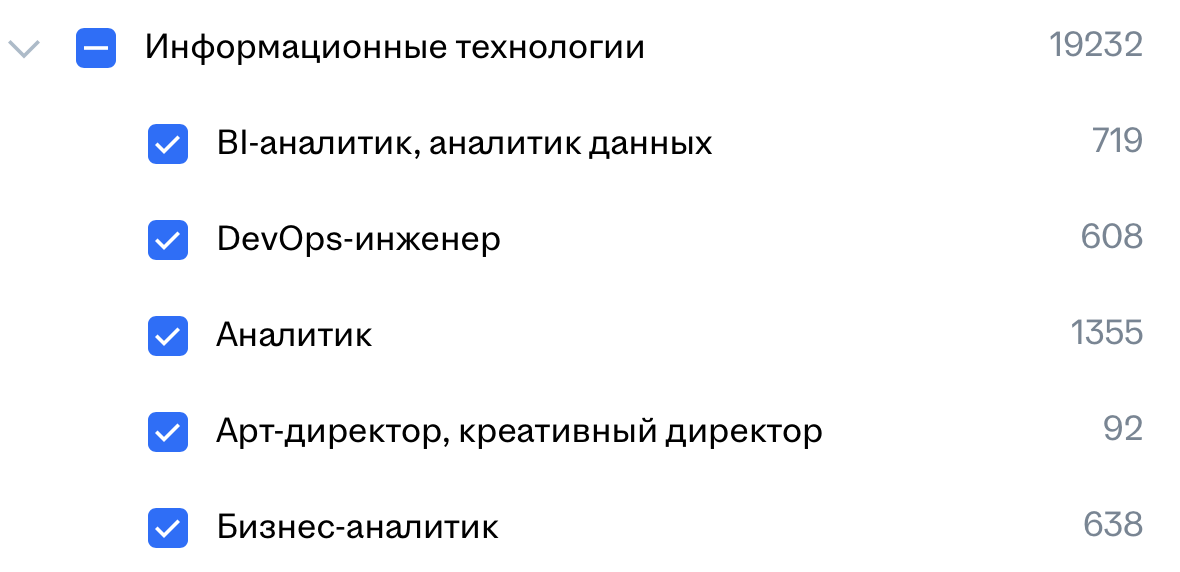

In [ ]:
url_hh1 = 'https://hh.ru/search/vacancy?area=113&L_save_area=true&search_field=name&search_field=company_name&search_field=description&enable_snippets=true&professional_role=134&professional_role=156&professional_role=160&professional_role=10&professional_role=12&professional_role=150'
page = requests.get(url_hh1)
page

In [ ]:
browser.get(url_hh1)
sleep(3)
html = browser.page_source
soup = BeautifulSoup(html, 'html.parser')
browser.title

In [ ]:
logging.info(f'Страница открывается: {url_hh1}')

In [ ]:
for link in soup.find_all('a'):
    print(link.get('href'))

In [ ]:
urls = []
for link in soup.find_all('a'):
  if link.get('href') is not None and 'hh.ru/vacancy/' in link.get('href'):
    href = link.get('href').split('?')[0]
    urls.append(href)
urls

In [ ]:
def get_page(p):
  url = f'{url_hh1}&page={p}'
  browser.get(url)
  sleep(5)
  logging.info(f'Открыта страница с ваканиями: {url}')
  soup = BeautifulSoup(browser.page_source, 'html.parser')

  urls = []

  for link in soup.find_all('a'):
    if link.get('href') is not None and 'hh.ru/vacancy/' in link.get('href'):
      href = link.get('href').split('?')[0]
      urls.append(href)
  urls = list(set(urls))
  logging.info(f'На странице {p} найдено {len(urls)} уникальных ссылок')
  return urls

In [ ]:
get_page(39)

In [ ]:
get_page(40)

In [ ]:
url = get_page(0)[1]
browser.get(url)
sleep(5)
soup = BeautifulSoup(browser.page_source, 'html.parser')
print(soup.prettify())

In [ ]:
def GetVacancy(url0):
  browser.get(url0)
  sleep(3)
  soup0 = BeautifulSoup(browser.page_source, 'html.parser')

  try:
    title = soup0.find('h1')
    title = title.get_text(strip=True)
  except AttributeError:
    title = None

  try:
    company = soup0.find(attrs={'data-qa': 'vacancy-company-name'})
    company = company.get_text(strip=True)
  except AttributeError:
    company = None

  try:
    salary = soup0.find(attrs={'data-qa': 'vacancy-salary'})
    salary = salary.get_text(' ', strip=True)
  except AttributeError:
    salary = None

  try:
    experience = soup0.find(attrs={'data-qa': 'vacancy-experience'})
    experience = experience.get_text(strip=True)
  except AttributeError:
    experience = None

  try:
    location = soup0.find(attrs={'data-qa': 'vacancy-view-location'})
    location = location.get_text(' ', strip=True)
  except AttributeError:
    location = None

  try:
    description = soup0.find(attrs={'data-qa': 'vacancy-description'})
    description = description.get_text(' ', strip=True)
  except AttributeError:
    description = None

  try:
    date = soup0.find('meta', {'property': 'article:published_time'}).get('content')
  except AttributeError:
    date = None

  try:
    tags_raw = soup0.find('ul', class_='vacancy-skill-list--JsTYRZ5o6dsoavK7')
    tags_raw = tags_raw.get_text(', ', strip=True)
  except AttributeError:
    tags_raw = None

  result = {
      'url': url0,
      'title': title,
      'date': date,
      'company': company,
      'salary': salary,
      'experience': experience,
      'location': location,
      'tags_raw': tags_raw,
      'description': description,
      'source': 'hh_ru'}
  logging.info(f'Вакансия {title} спарсена')
  return result

In [ ]:
url0 = get_page(0)[1]
GetVacancy(url0)

In [ ]:
infa = []

for p in tqdm(range(0,40)):
  try:
    infa.extend(get_page(p))
    sleep(5)
  except:
    print(p)
    logging.exception(f'Ошибка при обработке страницы {p}')
logging.info(f'Всего собрано {len(infa)} ссылок')

In [ ]:
vacancies_hh = []

for link in tqdm(infa):
  try:
    print(link)
    res = GetVacancy(link)
    vacancies_hh.append(res)
    sleep(3)
  except:
    print(link)
    logging.exception(f'Ошибка при парсинге вакансии {link}')
logging.info(f'Всего спарсено {len(vacancies_hh)} вакансий')

In [ ]:
df = pd.DataFrame(vacancies_hh)
df.head(2)
logging.info(f'Таблица вакансий hh создана')

In [ ]:
df.to_csv('hh.csv')
logging.info(f'Файл hh загружен')

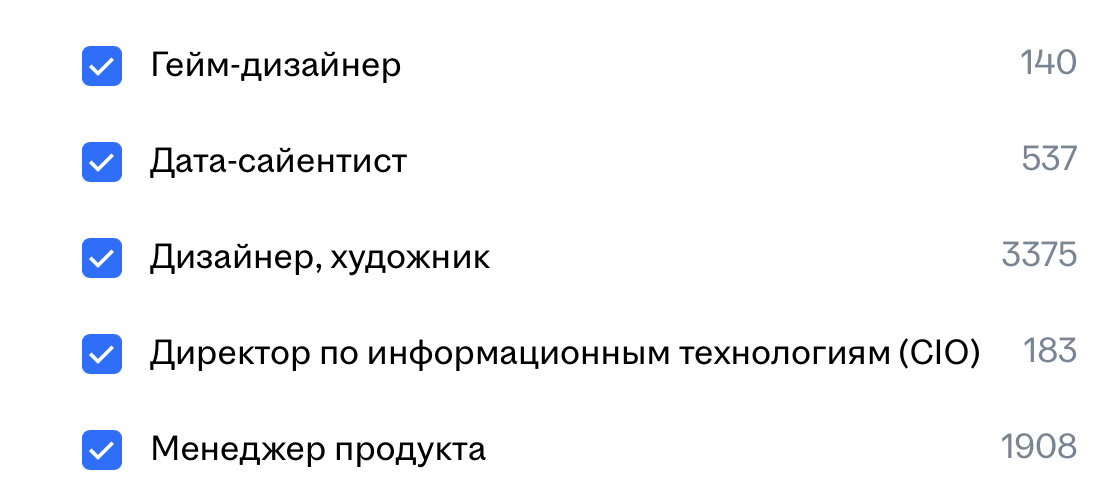

In [ ]:
url_hh2 = 'https://hh.ru/search/vacancy?area=113&L_save_area=true&search_field=name&search_field=company_name&search_field=description&enable_snippets=true&professional_role=25&professional_role=165&professional_role=34&professional_role=36&professional_role=73'
page = requests.get(url_hh2)
browser.get(url_hh2)
sleep(3)
html = browser.page_source
soup = BeautifulSoup(html, 'html.parser')
browser.title
logging.info(f'Страница открывается: {url_hh2}')
def get_page(p):
  url = f'{url_hh2}&page={p}'
  browser.get(url)
  sleep(3)
  logging.info(f'Открыта страница с ваканиями: {url}')
  soup = BeautifulSoup(browser.page_source, 'html.parser')

  urls = []

  for link in soup.find_all('a'):
    if link.get('href') is not None and 'hh.ru/vacancy/' in link.get('href'):
      href = link.get('href').split('?')[0]
      urls.append(href)
  urls = list(set(urls))
  logging.info(f'На странице {p} найдено {len(urls)} уникальных ссылок')
  return urls
def GetVacancy(url0):
  browser.get(url0)
  sleep(3)
  soup0 = BeautifulSoup(browser.page_source, 'html.parser')

  try:
    title = soup0.find('h1')
    title = title.get_text(strip=True)
  except AttributeError:
    title = None

  try:
    company = soup0.find(attrs={'data-qa': 'vacancy-company-name'})
    company = company.get_text(strip=True)
  except AttributeError:
    company = None

  try:
    salary = soup0.find(attrs={'data-qa': 'vacancy-salary'})
    salary = salary.get_text(' ', strip=True)
  except AttributeError:
    salary = None

  try:
    experience = soup0.find(attrs={'data-qa': 'vacancy-experience'})
    experience = experience.get_text(strip=True)
  except AttributeError:
    experience = None

  try:
    location = soup0.find(attrs={'data-qa': 'vacancy-view-location'})
    location = location.get_text(' ', strip=True)
  except AttributeError:
    location = None

  try:
    description = soup0.find(attrs={'data-qa': 'vacancy-description'})
    description = description.get_text(' ', strip=True)
  except AttributeError:
    description = None

  try:
    date = soup0.find('meta', {'property': 'article:published_time'}).get('content')
  except AttributeError:
    date = None

  try:
    tags_raw = soup0.find('ul', class_='vacancy-skill-list--JsTYRZ5o6dsoavK7')
    tags_raw = tags_raw.get_text(', ', strip=True)
  except AttributeError:
    tags_raw = None

  result = {
      'url': url0,
      'title': title,
      'date': date,
      'company': company,
      'salary': salary,
      'experience': experience,
      'location': location,
      'tags_raw': tags_raw,
      'description': description,
      'source': 'hh_ru'}
  logging.info(f'Вакансия {title} спарсена')
  return result

In [ ]:
infa = []

for p in tqdm(range(0,40)):
  try:
    infa.extend(get_page(p))
    sleep(5)
  except:
    print(p)
    logging.exception(f'Ошибка при обработке страницы {p}')
logging.info(f'Всего собрано {len(infa)} ссылок')

In [ ]:
vacancies_hh = []

for link in tqdm(infa):
  try:
    print(link)
    res = GetVacancy(link)
    vacancies_hh.append(res)
    sleep(5)
  except:
    print(link)
    logging.exception(f'Ошибка при парсинге вакансии {link}')
logging.info(f'Всего спарсено {len(vacancies_hh)} вакансий')

In [ ]:
df = pd.DataFrame(vacancies_hh)
df.head(2)
logging.info(f'Таблица вакансий hh2 создана')
df.to_csv('hh2.csv')
logging.info(f'Файл hh2 загружен')

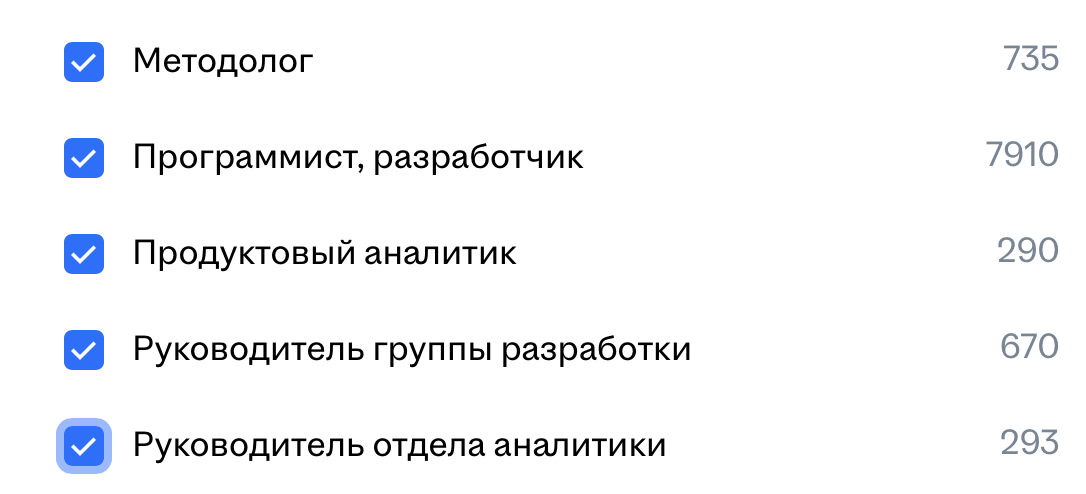

In [ ]:
url_hh3 = 'https://hh.ru/search/vacancy?area=113&L_save_area=true&search_field=name&search_field=company_name&search_field=description&enable_snippets=true&professional_role=155&professional_role=96&professional_role=164&professional_role=104&professional_role=157'
page = requests.get(url_hh3)
browser.get(url_hh3)
sleep(3)
html = browser.page_source
soup = BeautifulSoup(html, 'html.parser')
browser.title
logging.info(f'Страница открывается: {url_hh3}')
def get_page(p):
  url = f'{url_hh3}&page={p}'
  browser.get(url)
  sleep(3)
  logging.info(f'Открыта страница с ваканиями: {url}')
  soup = BeautifulSoup(browser.page_source, 'html.parser')

  urls = []

  for link in soup.find_all('a'):
    if link.get('href') is not None and 'hh.ru/vacancy/' in link.get('href'):
      href = link.get('href').split('?')[0]
      urls.append(href)
  urls = list(set(urls))
  logging.info(f'На странице {p} найдено {len(urls)} уникальных ссылок')
  return urls
def GetVacancy(url0):
  browser.get(url0)
  sleep(3)
  soup0 = BeautifulSoup(browser.page_source, 'html.parser')

  try:
    title = soup0.find('h1')
    title = title.get_text(strip=True)
  except AttributeError:
    title = None

  try:
    company = soup0.find(attrs={'data-qa': 'vacancy-company-name'})
    company = company.get_text(strip=True)
  except AttributeError:
    company = None

  try:
    salary = soup0.find(attrs={'data-qa': 'vacancy-salary'})
    salary = salary.get_text(' ', strip=True)
  except AttributeError:
    salary = None

  try:
    experience = soup0.find(attrs={'data-qa': 'vacancy-experience'})
    experience = experience.get_text(strip=True)
  except AttributeError:
    experience = None

  try:
    location = soup0.find(attrs={'data-qa': 'vacancy-view-location'})
    location = location.get_text(' ', strip=True)
  except AttributeError:
    location = None

  try:
    description = soup0.find(attrs={'data-qa': 'vacancy-description'})
    description = description.get_text(' ', strip=True)
  except AttributeError:
    description = None

  try:
    date = soup0.find('meta', {'property': 'article:published_time'}).get('content')
  except AttributeError:
    date = None

  try:
    tags_raw = soup0.find('ul', class_='vacancy-skill-list--JsTYRZ5o6dsoavK7')
    tags_raw = tags_raw.get_text(', ', strip=True)
  except AttributeError:
    tags_raw = None

  result = {
      'url': url0,
      'title': title,
      'date': date,
      'company': company,
      'salary': salary,
      'experience': experience,
      'location': location,
      'tags_raw': tags_raw,
      'description': description,
      'source': 'hh_ru'}
  logging.info(f'Вакансия {title} спарсена')
  return result

In [ ]:
infa = []

for p in tqdm(range(0,40)):
  try:
    infa.extend(get_page(p))
    sleep(5)
  except:
    print(p)
    logging.exception(f'Ошибка при обработке страницы {p}')
logging.info(f'Всего собрано {len(infa)} ссылок')

In [ ]:
vacancies_hh = []

for link in tqdm(infa):
  try:
    print(link)
    res = GetVacancy(link)
    vacancies_hh.append(res)
    sleep(5)
  except:
    print(link)
    logging.exception(f'Ошибка при парсинге вакансии {link}')
logging.info(f'Всего спарсено {len(vacancies_hh)} вакансий')

In [ ]:
df = pd.DataFrame(vacancies_hh)
df.head(2)
logging.info(f'Таблица вакансий hh3 создана')
df.to_csv('hh3.csv')
logging.info(f'Файл hh3 загружен')

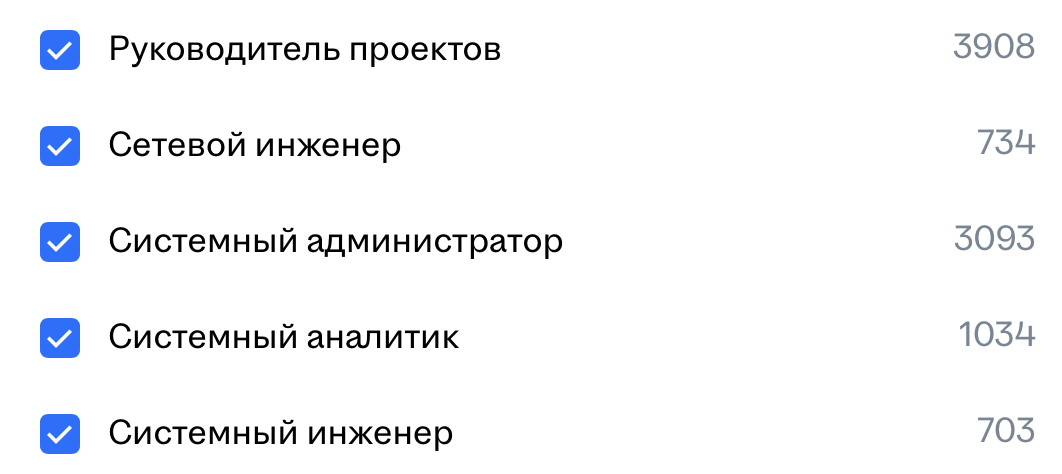

In [ ]:
url_hh4 = 'https://hh.ru/search/vacancy?area=113&L_save_area=true&search_field=name&search_field=company_name&search_field=description&enable_snippets=true&professional_role=107&professional_role=112&professional_role=113&professional_role=148&professional_role=114'
page = requests.get(url_hh4)
browser.get(url_hh4)
sleep(3)
html = browser.page_source
soup = BeautifulSoup(html, 'html.parser')
browser.title
logging.info(f'Страница открывается: {url_hh4}')
def get_page(p):
  url = f'{url_hh4}&page={p}'
  browser.get(url)
  sleep(3)
  logging.info(f'Открыта страница с ваканиями: {url}')
  soup = BeautifulSoup(browser.page_source, 'html.parser')

  urls = []

  for link in soup.find_all('a'):
    if link.get('href') is not None and 'hh.ru/vacancy/' in link.get('href'):
      href = link.get('href').split('?')[0]
      urls.append(href)
  urls = list(set(urls))
  logging.info(f'На странице {p} найдено {len(urls)} уникальных ссылок')
  return urls
def GetVacancy(url0):
  browser.get(url0)
  sleep(3)
  soup0 = BeautifulSoup(browser.page_source, 'html.parser')

  try:
    title = soup0.find('h1')
    title = title.get_text(strip=True)
  except AttributeError:
    title = None

  try:
    company = soup0.find(attrs={'data-qa': 'vacancy-company-name'})
    company = company.get_text(strip=True)
  except AttributeError:
    company = None

  try:
    salary = soup0.find(attrs={'data-qa': 'vacancy-salary'})
    salary = salary.get_text(' ', strip=True)
  except AttributeError:
    salary = None

  try:
    experience = soup0.find(attrs={'data-qa': 'vacancy-experience'})
    experience = experience.get_text(strip=True)
  except AttributeError:
    experience = None

  try:
    location = soup0.find(attrs={'data-qa': 'vacancy-view-location'})
    location = location.get_text(' ', strip=True)
  except AttributeError:
    location = None

  try:
    description = soup0.find(attrs={'data-qa': 'vacancy-description'})
    description = description.get_text(' ', strip=True)
  except AttributeError:
    description = None

  try:
    date = soup0.find('meta', {'property': 'article:published_time'}).get('content')
  except AttributeError:
    date = None

  try:
    tags_raw = soup0.find('ul', class_='vacancy-skill-list--JsTYRZ5o6dsoavK7')
    tags_raw = tags_raw.get_text(', ', strip=True)
  except AttributeError:
    tags_raw = None

  result = {
      'url': url0,
      'title': title,
      'date': date,
      'company': company,
      'salary': salary,
      'experience': experience,
      'location': location,
      'tags_raw': tags_raw,
      'description': description,
      'source': 'hh_ru'}
  logging.info(f'Вакансия {title} спарсена')
  return result

In [ ]:
infa = []

for p in tqdm(range(0,40)):
  try:
    infa.extend(get_page(p))
    sleep(5)
  except:
    print(p)
    logging.exception(f'Ошибка при обработке страницы {p}')
logging.info(f'Всего собрано {len(infa)} ссылок')

In [ ]:
vacancies_hh = []

for link in tqdm(infa):
  try:
    print(link)
    res = GetVacancy(link)
    vacancies_hh.append(res)
    sleep(5)
  except:
    print(link)
    logging.exception(f'Ошибка при парсинге вакансии {link}')
logging.info(f'Всего спарсено {len(vacancies_hh)} вакансий')

In [ ]:
df = pd.DataFrame(vacancies_hh)
df.head(2)
logging.info(f'Таблица вакансий hh4 создана')
df.to_csv('hh4.csv')
logging.info(f'Файл hh4 загружен')

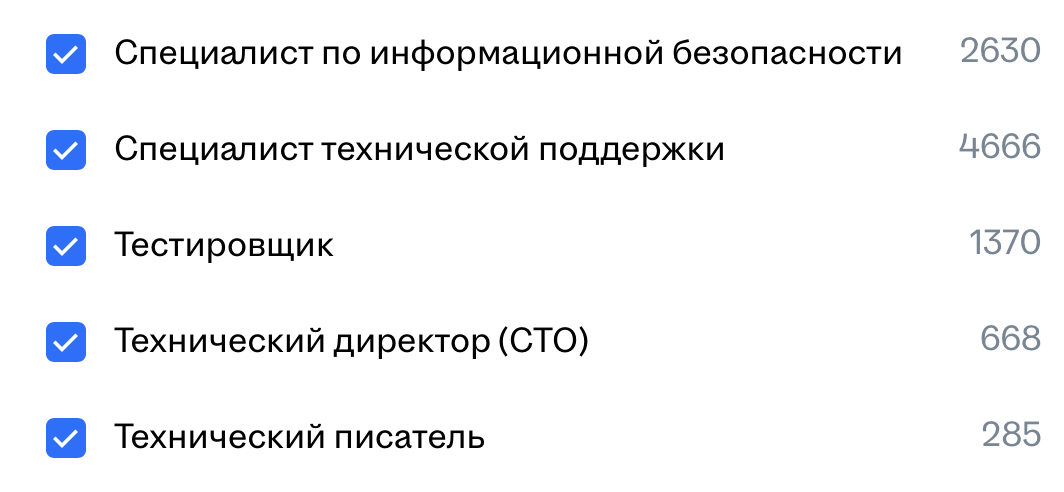

In [ ]:
url_hh5 = 'https://hh.ru/search/vacancy?area=113&L_save_area=true&search_field=name&search_field=company_name&search_field=description&enable_snippets=true&professional_role=126&professional_role=125&professional_role=124&professional_role=121&professional_role=116'
page = requests.get(url_hh5)
browser.get(url_hh5)
sleep(3)
html = browser.page_source
soup = BeautifulSoup(html, 'html.parser')
browser.title
logging.info(f'Страница открывается: {url_hh5}')
def get_page5(p):
  url = f'{url_hh5}&page={p}'
  browser.get(url)
  sleep(3)
  logging.info(f'Открыта страница с ваканиями: {url}')
  soup = BeautifulSoup(browser.page_source, 'html.parser')

  urls = []

  for link in soup.find_all('a'):
    if link.get('href') is not None and 'hh.ru/vacancy/' in link.get('href'):
      href = link.get('href').split('?')[0]
      urls.append(href)
  urls = list(set(urls))
  logging.info(f'На странице {p} найдено {len(urls)} уникальных ссылок')
  return urls
def GetVacancy(url0):
  browser.get(url0)
  sleep(3)
  soup0 = BeautifulSoup(browser.page_source, 'html.parser')

  try:
    title = soup0.find('h1')
    title = title.get_text(strip=True)
  except AttributeError:
    title = None

  try:
    company = soup0.find(attrs={'data-qa': 'vacancy-company-name'})
    company = company.get_text(strip=True)
  except AttributeError:
    company = None

  try:
    salary = soup0.find(attrs={'data-qa': 'vacancy-salary'})
    salary = salary.get_text(' ', strip=True)
  except AttributeError:
    salary = None

  try:
    experience = soup0.find(attrs={'data-qa': 'vacancy-experience'})
    experience = experience.get_text(strip=True)
  except AttributeError:
    experience = None

  try:
    location = soup0.find(attrs={'data-qa': 'vacancy-view-location'})
    location = location.get_text(' ', strip=True)
  except AttributeError:
    location = None

  try:
    description = soup0.find(attrs={'data-qa': 'vacancy-description'})
    description = description.get_text(' ', strip=True)
  except AttributeError:
    description = None

  try:
    date = soup0.find('meta', {'property': 'article:published_time'}).get('content')
  except AttributeError:
    date = None

  try:
    tags_raw = soup0.find('ul', class_='vacancy-skill-list--JsTYRZ5o6dsoavK7')
    tags_raw = tags_raw.get_text(', ', strip=True)
  except AttributeError:
    tags_raw = None

  result = {
      'url': url0,
      'title': title,
      'date': date,
      'company': company,
      'salary': salary,
      'experience': experience,
      'location': location,
      'tags_raw': tags_raw,
      'description': description,
      'source': 'hh_ru'}
  logging.info(f'Вакансия {title} спарсена')
  return result

In [ ]:
infa = []

for p in tqdm(range(0,40)):
  try:
    infa.extend(get_page(p))
    sleep(5)
  except:
    print(p)
    logging.exception(f'Ошибка при обработке страницы {p}')
logging.info(f'Всего собрано {len(infa)} ссылок')

In [ ]:
vacancies_hh = []

for link in tqdm(infa):
  try:
    print(link)
    res = GetVacancy(link)
    vacancies_hh.append(res)
    sleep(5)
  except:
    print(link)
    logging.exception(f'Ошибка при парсинге вакансии {link}')
logging.info(f'Всего спарсено {len(vacancies_hh)} вакансий')

In [ ]:
df = pd.DataFrame(vacancies_hh)
df.head(2)
logging.info(f'Таблица вакансий hh5 создана')
df.to_csv('hh5.csv')
logging.info(f'Файл hh5 загружен')

In [ ]:
browser.quit()
logging.info(f'Browser закрыт')